# Wolff vs. Metropolis: Algorithmic Efficiency in the Critical Regime

Near a second-order phase transition, standard Metropolis–Hastings [[1]](#Bibliography) suffers from *critical slowing down*: the integrated autocorrelation time $\tau_{\mathrm{int}}$ grows as $\tau_{\mathrm{int}} \sim L^z$, with a dynamic critical exponent $z \approx 2.17$ for the 2D Ising model. Physically, successive spin configurations generated by single-site flips remain highly correlated for many steps because proposed flips within a large correlated domain are overwhelmingly rejected and the system cannot efficiently cross free-energy barriers by small local moves.

The Wolff cluster algorithm [[2]](#Bibliography) eliminates this bottleneck directly. Rather than proposing a single-spin flip, Wolff grows a cluster from a random seed by probabilistically bonding same-sign nearest neighbours with probability $P_{\mathrm{add}} = 1 - e^{-2\beta J}$, then flips the entire cluster in one accepted collective move. The bond probability is derived from the Fortuin–Kasteleyn random-cluster representation [[3]](#Bibliography) and guarantees detailed balance without any rejections. The dynamic critical exponent drops to $z \approx 0.25$, nearly an order of magnitude smaller than Metropolis.

The practical benefit is regime-dependent. Far below $T_c$ the equilibrium state is a single near-spanning ferromagnetic domain; all grown clusters are system-spanning and flipping them merely reverses the global magnetisation without decorrelating the configuration. Far above $T_c$ the correlation length is short and clusters are vanishingly small, so the BFS overhead dominates. The Wolff advantage is concentrated in the window $|T - T_c| \lesssim 0.2\,T_c$ where $\xi$ is large but finite. For a comprehensive review of these methods, see Newman and Barkema [[4]](#Bibliography).

## The normalization problem

A naive comparison of $\tau_{\mathrm{int}}$ step counts between the two algorithms is **misleading** because the algorithms do different amounts of physical work per recorded step:

| Algorithm | Work per step |
|-----------|---------------|
| Metropolis (checkerboard) | $L^2$ single-spin flip *attempts* — one full lattice sweep |
| Wolff cluster | 1 cluster flip of $\langle C \rangle$ spins — 100% acceptance rate |

Counting raw steps treats a Wolff step at $T \gg T_c$ (where $\langle C \rangle \approx 1$ spin) as equivalent to a Metropolis step that touches all $L^2$ spins. This makes Wolff appear arbitrarily fast in the disordered phase for the wrong reason, and artificially slow below $T_c$ where clusters are nearly system-spanning. Neither conclusion reflects the actual computational cost.

The standard fix is to express autocorrelation time in units of one $L^2$ flip-attempt sweep:
$$\tau^{\mathrm{norm}}_{\mathrm{metro}} = \tau_{\mathrm{steps}} \qquad\qquad \tau^{\mathrm{norm}}_{\mathrm{Wolff}} = \tau_{\mathrm{steps}} \times \frac{\langle C \rangle}{L^2}$$

where $\langle C \rangle$ is the mean cluster size measured from recorded per-step cluster sizes. After normalisation, both algorithms are on the same ruler: how many equivalent full-lattice sweep attempts are needed to decorrelate.

This notebook therefore reports two complementary views:
- **work-normalised $\tau_{\mathrm{int}}$** for fair cross-algorithm decorrelation-cost comparison,
- **ISS in 1/s** (independent samples per second), which is unit-invariant under update-unit rescaling and therefore directly comparable without extra scaling.

In [7]:
from __future__ import annotations

import os
import time

import matplotlib.pyplot as plt
import numpy as np

TC_ISING: float = 2.0 / np.log(1.0 + np.sqrt(2.0))
PALETTE = {'metro': '#4878CF', 'wolff': '#D65F5F'}

print(f'Exact Onsager T_c = {TC_ISING:.6f}')

Exact Onsager T_c = 2.269185


## Load or compute data

This notebook compares the independent-sample rate and autocorrelation structure of **checkerboard Metropolis** and Wolff dynamics across temperature. It first searches for precomputed measurements at `../results/ising/wolff_efficiency.npz`.

When the cache file is present, the notebook loads robust summaries (median and 16–84% bands across seeds) and, when available, per-seed sample arrays for uncertainty-aware analysis. The same plotting code also supports legacy caches that only contain single-value arrays.

When the cache file is absent, the notebook runs a small inline fallback (`L=16`, 8 temperature points, several seed replicas) so the workflow remains self-contained. This fallback is useful for validating analysis logic and plotting, but it is intentionally small and should be treated as demo quality.

For publication-quality data, run:
```bash
python scripts/ising/wolff_efficiency.py --size 64 --t-points 20 --n-seeds 10 --meas-steps 2000
```
This stores both aggregate statistics and per-seed arrays in `../results/ising/wolff_efficiency.npz` for reuse on subsequent notebook runs.

In [ ]:
NPZ_PATH = '../results/ising/wolff_efficiency.npz'


def _bands_from_samples(samples: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    med = np.nanmedian(samples, axis=1)
    p16 = np.nanpercentile(samples, 16, axis=1)
    p84 = np.nanpercentile(samples, 84, axis=1)
    return med, p16, p84


_cache_ok = False
if os.path.exists(NPZ_PATH):
    data = np.load(NPZ_PATH)
    _required = {
        'temperatures', 'tau_metro', 'tau_wolff',
        'iss_metro', 'iss_wolff', 'mean_cluster_frac',
        'chi_metro', 'chi_wolff', 'L',
    }
    if _required.issubset(set(data.files)):
        temperatures = data['temperatures']
        tau_metro = data['tau_metro']
        tau_wolff = data['tau_wolff']
        iss_metro = data['iss_metro']
        iss_wolff = data['iss_wolff']
        mean_cluster_frac = data['mean_cluster_frac']
        chi_metro = data['chi_metro']
        chi_wolff = data['chi_wolff']
        L = int(data['L'])

        have_samples = {
            'tau_metro_samples', 'tau_wolff_samples',
            'iss_metro_samples', 'iss_wolff_samples',
            'mean_cluster_frac_samples',
            'chi_metro_samples', 'chi_wolff_samples',
        }.issubset(set(data.files))

        if have_samples:
            tau_metro_samples = data['tau_metro_samples']
            tau_wolff_samples = data['tau_wolff_samples']
            iss_metro_samples = data['iss_metro_samples']
            iss_wolff_samples = data['iss_wolff_samples']
            mean_cluster_frac_samples = data['mean_cluster_frac_samples']
            chi_metro_samples = data['chi_metro_samples']
            chi_wolff_samples = data['chi_wolff_samples']
            n_seeds = int(data['n_seeds']) if 'n_seeds' in data.files else int(tau_metro_samples.shape[1])

            tau_metro, tau_metro_p16, tau_metro_p84 = _bands_from_samples(tau_metro_samples)
            tau_wolff, tau_wolff_p16, tau_wolff_p84 = _bands_from_samples(tau_wolff_samples)
            iss_metro, iss_metro_p16, iss_metro_p84 = _bands_from_samples(iss_metro_samples)
            iss_wolff, iss_wolff_p16, iss_wolff_p84 = _bands_from_samples(iss_wolff_samples)
            mean_cluster_frac, mean_cluster_frac_p16, mean_cluster_frac_p84 = _bands_from_samples(mean_cluster_frac_samples)
            chi_metro, chi_metro_p16, chi_metro_p84 = _bands_from_samples(chi_metro_samples)
            chi_wolff, chi_wolff_p16, chi_wolff_p84 = _bands_from_samples(chi_wolff_samples)

            print(
                f'Loaded pre-computed data: L={L}, {len(temperatures)} temperature points, '
                f'{n_seeds} seed replicas.'
            )
        else:
            # Legacy cache compatibility: synthesize singleton sample dimension.
            tau_metro_samples = tau_metro[:, None]
            tau_wolff_samples = tau_wolff[:, None]
            iss_metro_samples = iss_metro[:, None]
            iss_wolff_samples = iss_wolff[:, None]
            mean_cluster_frac_samples = mean_cluster_frac[:, None]
            chi_metro_samples = chi_metro[:, None]
            chi_wolff_samples = chi_wolff[:, None]
            n_seeds = 1

            tau_metro_p16 = tau_metro_p84 = tau_metro
            tau_wolff_p16 = tau_wolff_p84 = tau_wolff
            iss_metro_p16 = iss_metro_p84 = iss_metro
            iss_wolff_p16 = iss_wolff_p84 = iss_wolff
            mean_cluster_frac_p16 = mean_cluster_frac_p84 = mean_cluster_frac
            chi_metro_p16 = chi_metro_p84 = chi_metro
            chi_wolff_p16 = chi_wolff_p84 = chi_wolff

            print(
                f'Loaded legacy cache: L={L}, {len(temperatures)} temperature points, '
                'no seed uncertainty arrays.'
            )

        _cache_ok = True
    else:
        print(f'Cache at {NPZ_PATH} is missing expected keys; running inline fallback.')

if not _cache_ok:
    print('Pre-computed data not found. Running inline demo (L=16, 8 T-points, 5 seeds, ~2–4 min)...')
    from models.ising_model import IsingSimulation
    from utils.exceptions import ZeroVarianceAutocorrelationError
    from utils.physics_helpers import calculate_autocorr, calculate_thermodynamics
    from utils.system_helpers import convergence_equilibrate

    L = 16
    temperatures = np.linspace(1.8, 3.2, 8)
    EQ_CHUNK, EQ_MAX, MEAS = 100, 10000, 500
    n_seeds = 5
    n_temp = len(temperatures)

    tau_metro_samples = np.full((n_temp, n_seeds), np.nan)
    tau_wolff_samples = np.full((n_temp, n_seeds), np.nan)
    iss_metro_samples = np.full((n_temp, n_seeds), np.nan)
    iss_wolff_samples = np.full((n_temp, n_seeds), np.nan)
    mean_cluster_frac_samples = np.full((n_temp, n_seeds), np.nan)
    chi_metro_samples = np.full((n_temp, n_seeds), np.nan)
    chi_wolff_samples = np.full((n_temp, n_seeds), np.nan)

    for i, T in enumerate(temperatures):
        for s in range(n_seeds):
            base_seed = i * 1000 + s * 50

            # -- Metropolis (checkerboard) --
            sim_m_r = IsingSimulation(size=L, temp=T, update='checkerboard', init_state='random', seed=base_seed)
            sim_m_o = IsingSimulation(size=L, temp=T, update='checkerboard', init_state='ordered', seed=base_seed)
            convergence_equilibrate(sim_m_r, sim_m_o, chunk_size=EQ_CHUNK, max_steps=EQ_MAX)

            t0 = time.perf_counter()
            mags_m, engs_m = sim_m_r.run(n_steps=MEAS)
            t_m = time.perf_counter() - t0
            mags_m_a = np.array(mags_m)
            try:
                _, tau_m = calculate_autocorr(time_series=mags_m_a)
            except (ZeroVarianceAutocorrelationError, ValueError):
                tau_m = float('nan')
            _, _, chi_m, _ = calculate_thermodynamics(
                mags=mags_m_a, engs=np.array(engs_m), T=T, L=L,
            )
            iss_m = (MEAS / t_m) / tau_m if np.isfinite(tau_m) and tau_m > 0 else float('nan')

            # -- Wolff --
            sim_w_r = IsingSimulation(size=L, temp=T, update='wolff', init_state='random', seed=base_seed + 1)
            sim_w_o = IsingSimulation(size=L, temp=T, update='wolff', init_state='ordered', seed=base_seed + 1)
            convergence_equilibrate(sim_w_r, sim_w_o, chunk_size=EQ_CHUNK, max_steps=EQ_MAX)

            t0 = time.perf_counter()
            mags_w, engs_w = sim_w_r.run(n_steps=MEAS)
            t_w = time.perf_counter() - t0
            mags_w_a = np.array(mags_w)
            try:
                _, tau_w = calculate_autocorr(time_series=mags_w_a)
            except (ZeroVarianceAutocorrelationError, ValueError):
                tau_w = float('nan')
            _, _, chi_w, _ = calculate_thermodynamics(
                mags=mags_w_a, engs=np.array(engs_w), T=T, L=L,
            )
            iss_w = (MEAS / t_w) / tau_w if np.isfinite(tau_w) and tau_w > 0 else float('nan')

            # -- Cluster sizes --
            _, _, cluster_sizes_arr = sim_w_r.run_with_cluster_sizes(n_steps=min(MEAS, 300))
            cfrac = float(np.mean(cluster_sizes_arr)) / (L * L)

            tau_metro_samples[i, s] = tau_m
            tau_wolff_samples[i, s] = tau_w
            iss_metro_samples[i, s] = iss_m
            iss_wolff_samples[i, s] = iss_w
            mean_cluster_frac_samples[i, s] = cfrac
            chi_metro_samples[i, s] = chi_m
            chi_wolff_samples[i, s] = chi_w

        print(f'  T={T:.2f} complete ({n_seeds} seeds)', flush=True)

    tau_metro, tau_metro_p16, tau_metro_p84 = _bands_from_samples(tau_metro_samples)
    tau_wolff, tau_wolff_p16, tau_wolff_p84 = _bands_from_samples(tau_wolff_samples)
    iss_metro, iss_metro_p16, iss_metro_p84 = _bands_from_samples(iss_metro_samples)
    iss_wolff, iss_wolff_p16, iss_wolff_p84 = _bands_from_samples(iss_wolff_samples)
    mean_cluster_frac, mean_cluster_frac_p16, mean_cluster_frac_p84 = _bands_from_samples(mean_cluster_frac_samples)
    chi_metro, chi_metro_p16, chi_metro_p84 = _bands_from_samples(chi_metro_samples)
    chi_wolff, chi_wolff_p16, chi_wolff_p84 = _bands_from_samples(chi_wolff_samples)
    print('Inline fallback complete.')

Loaded pre-computed data: L=64, 20 temperature points, 10 seed replicas.


## Work normalisation

Raw `tau_wolff` values count Wolff cluster updates, not full-lattice sweep equivalents. Before comparing dynamics, we convert both algorithms to the same work unit: one $L^2$-flip-attempt sweep.

Metropolis (checkerboard) already touches $L^2$ spins per step, so:
$$\tau^{\mathrm{norm}}_{\mathrm{metro}} = \tau_{\mathrm{metro}}.$$

Wolff touches $\langle C \rangle$ spins per step, so:
$$\tau^{\mathrm{norm}}_{\mathrm{Wolff}} = \tau_{\mathrm{Wolff}} \times \frac{\langle C \rangle}{L^2}.$$

The cluster fraction $\langle C \rangle / L^2$ is measured directly from per-step cluster sizes (`run_with_cluster_sizes`), not inferred from a proxy.

### Why ISS itself is unit-invariant

ISS has units of inverse time (independent samples per second):
$$\mathrm{ISS} = \frac{\text{updates/s}}{\tau_{\text{in updates}}}.$$ 
If we rescale the update unit (cluster updates \(\leftrightarrow\) sweep equivalents), both numerator and denominator are multiplied by the same factor and cancel exactly. Therefore ISS is invariant under this conversion.

So in this notebook:
- we **normalise $\tau$ explicitly** for algorithm-comparison plots,
- and we keep ISS numerically unchanged (but report uncertainty bands across seeds).

In [13]:
# Work-normalisation: convert tau to L²-sweep equivalents.
# mean_cluster_frac = <C> / L²  (recorded per-step from run_with_cluster_sizes)
L2 = L * L

# Median normalised autocorrelation times
tau_metro_norm = tau_metro
tau_wolff_norm = tau_wolff * mean_cluster_frac

# Seed-level normalised tau for uncertainty propagation
tau_metro_norm_samples = tau_metro_samples
tau_wolff_norm_samples = tau_wolff_samples * mean_cluster_frac_samples

def _bands(samples: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    med = np.nanmedian(samples, axis=1)
    p16 = np.nanpercentile(samples, 16, axis=1)
    p84 = np.nanpercentile(samples, 84, axis=1)
    return med, p16, p84

tau_metro_norm, tau_metro_norm_p16, tau_metro_norm_p84 = _bands(tau_metro_norm_samples)
tau_wolff_norm, tau_wolff_norm_p16, tau_wolff_norm_p84 = _bands(tau_wolff_norm_samples)

# ISS is unit-invariant under update-unit rescaling, so keep values unchanged.
iss_metro_norm = iss_metro
iss_wolff_norm = iss_wolff
iss_metro_norm_samples = iss_metro_samples
iss_wolff_norm_samples = iss_wolff_samples
iss_metro_norm, iss_metro_norm_p16, iss_metro_norm_p84 = _bands(iss_metro_norm_samples)
iss_wolff_norm, iss_wolff_norm_p16, iss_wolff_norm_p84 = _bands(iss_wolff_norm_samples)

print(f'L = {L},  N = L² = {L2},  seed replicas = {n_seeds}')
print('\nMean cluster size fraction <C>/L² per temperature (median [16th,84th]):')
for T, c, c16, c84 in zip(temperatures, mean_cluster_frac, mean_cluster_frac_p16, mean_cluster_frac_p84):
    print(f'  T = {T:.3f}:  {c:.4f} [{c16:.4f}, {c84:.4f}]  (<C> ≈ {c * L2:.1f} spins)')

print('\nWork-normalised tau_int (L²-sweep equivalents), median [16th,84th]:')
hdr = f'  {"T":>6}  {"tau_metro_norm":>24}  {"tau_wolff_norm":>24}'
print(hdr)
for T, tm, tm16, tm84, tw, tw16, tw84 in zip(
    temperatures,
    tau_metro_norm, tau_metro_norm_p16, tau_metro_norm_p84,
    tau_wolff_norm, tau_wolff_norm_p16, tau_wolff_norm_p84,
):
    print(
        f'  {T:>6.3f}  '
        f'{tm:>8.3f} [{tm16:>7.3f}, {tm84:>7.3f}]  '
        f'{tw:>8.3f} [{tw16:>7.3f}, {tw84:>7.3f}]'
    )

L = 64,  N = L² = 4096,  seed replicas = 10

Mean cluster size fraction <C>/L² per temperature (median [16th,84th]):
  T = 1.800:  0.9103 [0.9026, 0.9215]  (<C> ≈ 3728.7 spins)
  T = 1.874:  0.8995 [0.8867, 0.9030]  (<C> ≈ 3684.2 spins)
  T = 1.947:  0.8620 [0.8435, 0.8759]  (<C> ≈ 3530.7 spins)
  T = 2.021:  0.8211 [0.7984, 0.8377]  (<C> ≈ 3363.4 spins)
  T = 2.095:  0.7514 [0.7441, 0.7708]  (<C> ≈ 3077.6 spins)
  T = 2.168:  0.6742 [0.6513, 0.6893]  (<C> ≈ 2761.6 spins)
  T = 2.242:  0.5008 [0.4696, 0.5246]  (<C> ≈ 2051.3 spins)
  T = 2.316:  0.1607 [0.1418, 0.1831]  (<C> ≈ 658.1 spins)
  T = 2.389:  0.0483 [0.0418, 0.0508]  (<C> ≈ 197.6 spins)
  T = 2.463:  0.0212 [0.0170, 0.0231]  (<C> ≈ 86.6 spins)
  T = 2.537:  0.0114 [0.0103, 0.0129]  (<C> ≈ 46.7 spins)
  T = 2.611:  0.0069 [0.0065, 0.0085]  (<C> ≈ 28.4 spins)
  T = 2.684:  0.0053 [0.0047, 0.0062]  (<C> ≈ 21.6 spins)
  T = 2.758:  0.0037 [0.0034, 0.0043]  (<C> ≈ 15.3 spins)
  T = 2.832:  0.0034 [0.0031, 0.0038]  (<C> ≈ 13.8 spin

## Four-panel overview

The four panels show the efficiency landscape across temperature using **median values with 16–84% uncertainty bands** from seed replicas.

**Top-left — $\tau^{\mathrm{norm}}_{\mathrm{int}}(T)$:** Autocorrelation times in $L^2$-sweep equivalents. This is the correct work-comparable view of decorrelation cost. Metropolis peaks sharply near $T_c$ (critical slowing down), while Wolff remains much lower.

**Top-right — ISS$(T)$ (log scale):** Independent samples per second with seed-uncertainty bands. ISS is unit-invariant under update-unit rescaling, so values are unchanged by the $\tau$ normalisation step. The log axis exposes both crossover structure and order-of-magnitude separations.

**Bottom-left — $\langle C \rangle / L^2(T)$:** Mean cluster-size fraction (with uncertainty). This is the Wolff work-normalisation factor and the physical mechanism behind reduced critical slowing down.

**Bottom-right — $\chi(T)$:** Susceptibility agreement between algorithms (with uncertainty). Agreement confirms both updates sample the same equilibrium distribution; systematic disagreement would indicate a correctness issue.

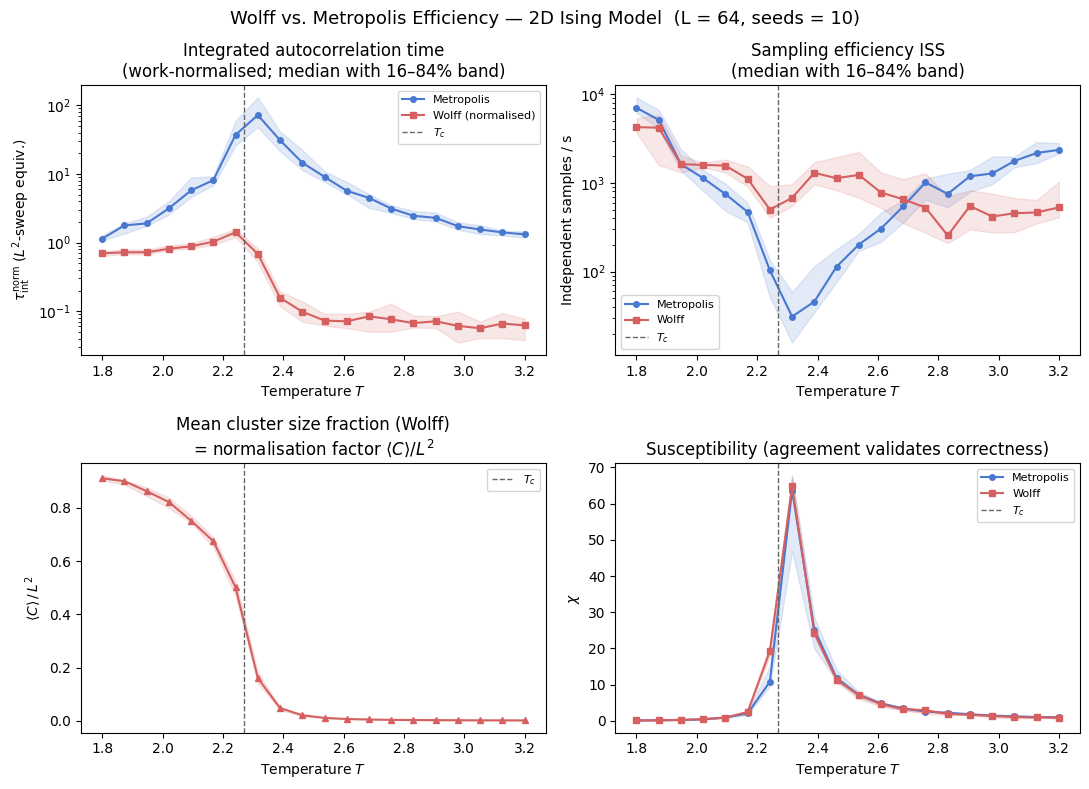

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(
    f'Wolff vs. Metropolis Efficiency — 2D Ising Model  (L = {L}, seeds = {n_seeds})', fontsize=13,
)

# tau_int_norm(T) — work-normalised, L²-sweep equivalents
ax = axes[0, 0]
ax.semilogy(temperatures, tau_metro_norm, '-o', color=PALETTE['metro'], ms=4, label='Metropolis')
ax.semilogy(temperatures, tau_wolff_norm, '-s', color=PALETTE['wolff'], ms=4, label='Wolff (normalised)')
ax.fill_between(temperatures, tau_metro_norm_p16, tau_metro_norm_p84, color=PALETTE['metro'], alpha=0.15)
ax.fill_between(temperatures, tau_wolff_norm_p16, tau_wolff_norm_p84, color=PALETTE['wolff'], alpha=0.15)
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'$\tau^{\mathrm{norm}}_{\mathrm{int}}$ ($L^2$-sweep equiv.)')
ax.set_title('Integrated autocorrelation time\n(work-normalised; median with 16–84% band)')
ax.legend(fontsize=8)

# ISS(T) — unit-invariant under update-unit conversion; log scale improves readability
ax = axes[0, 1]
ax.semilogy(temperatures, iss_metro_norm, '-o', color=PALETTE['metro'], ms=4, label='Metropolis')
ax.semilogy(temperatures, iss_wolff_norm, '-s', color=PALETTE['wolff'], ms=4, label='Wolff')
ax.fill_between(temperatures, iss_metro_norm_p16, iss_metro_norm_p84, color=PALETTE['metro'], alpha=0.15)
ax.fill_between(temperatures, iss_wolff_norm_p16, iss_wolff_norm_p84, color=PALETTE['wolff'], alpha=0.15)
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel('Independent samples / s')
ax.set_title('Sampling efficiency ISS\n(median with 16–84% band)')
ax.legend(fontsize=8)

# mean cluster size fraction — normalisation factor
ax = axes[1, 0]
ax.plot(temperatures, mean_cluster_frac, '-^', color=PALETTE['wolff'], ms=4)
ax.fill_between(temperatures, mean_cluster_frac_p16, mean_cluster_frac_p84, color=PALETTE['wolff'], alpha=0.15)
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'$\langle C \rangle \,/\, L^2$')
ax.set_title(r'Mean cluster size fraction (Wolff)' + '\n' + r'= normalisation factor $\langle C\rangle/L^2$')
ax.legend(fontsize=8)

# chi consistency
ax = axes[1, 1]
ax.plot(temperatures, chi_metro, '-o', color=PALETTE['metro'], ms=4, label='Metropolis')
ax.plot(temperatures, chi_wolff, '-s', color=PALETTE['wolff'], ms=4, label='Wolff')
ax.fill_between(temperatures, chi_metro_p16, chi_metro_p84, color=PALETTE['metro'], alpha=0.15)
ax.fill_between(temperatures, chi_wolff_p16, chi_wolff_p84, color=PALETTE['wolff'], alpha=0.15)
ax.axvline(TC_ISING, color='0.4', ls='--', lw=1, label=r'$T_c$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'$\chi$')
ax.set_title(r'Susceptibility (agreement validates correctness)')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

The four panels now combine two complementary quality dimensions: physically consistent work normalisation for $\tau_{\mathrm{int}}$ and seed-level uncertainty reporting (median with 16–84% bands) for all plotted observables. The top-left panel compares decorrelation cost in equivalent sweep units; the top-right panel reports ISS directly in 1/s, which is invariant under update-unit rescaling. The bottom-left panel shows the normalisation factor $\langle C \rangle / L^2$, and the bottom-right panel verifies equilibrium consistency through susceptibility agreement.

## The mechanism: correlated clusters and the FK representation

The connection between cluster size and decorrelation efficiency is quantitative. In the FK representation, activated bonds mark pairs of spins that are constrained to flip together. The cluster grown by Wolff at temperature $T$ and system size $L$ has a mean size that scales as $\langle C \rangle \sim \xi^{d_f}$, where $\xi \sim |T - T_c|^{-\nu}$ is the correlation length and $d_f = 15/8$ is the fractal dimension of the critical cluster. At $T_c$ and in the thermodynamic limit, $\langle C \rangle \sim L^{d_f}$ — the cluster spans a macroscopic fraction of the lattice on every accepted move.

This is precisely the regime where Metropolis fails: near $T_c$, the equilibrium configurations are dominated by large correlated domains, and single-site Metropolis proposals almost always attempt to break a bond that costs a large energy penalty, leading to exponentially suppressed acceptance rates and long autocorrelation times. Wolff bypasses this by accepting every cluster flip, shifting the statistical complexity into the FK bond-sampling step rather than the spin-flip decision.

### Regime-by-regime picture

**At $T_c$:** Clusters cover a macroscopic fraction of the lattice ($\langle C \rangle \sim L^{d_f}$). Each Wolff step flips a large correlated block, so even though this costs $\langle C \rangle / L^2 \approx 0.3$–$0.5$ normalised sweep equivalents per step, the raw $\tau$ in steps is already far smaller than Metropolis. The normalised advantage is therefore real: Wolff delivers independent samples at lower normalised cost.

**Below $T_c$:** The lattice is nearly monochromatic and clusters are nearly system-spanning ($\langle C \rangle / L^2 \to 1$). Flipping a system-spanning cluster changes the sign of the total magnetisation but does not decorrelate the microscopic structure — the system just tunnels between the $+M$ and $-M$ wells. The raw $\tau_{\mathrm{int}}$ in steps looks small, but after normalisation ($\tau_{\mathrm{norm}} = \tau_{\mathrm{steps}} \times \langle C \rangle / L^2 \approx \tau_{\mathrm{steps}}$) the advantage over Metropolis is modest. The real Wolff gain below $T_c$ is tunnelling the free-energy barrier between magnetisation sectors in one step — something Metropolis cannot do at all in the ordered phase for large $L$.

**Above $T_c$:** The correlation length is short and clusters are tiny ($\langle C \rangle \approx O(1)$). A Wolff step touches almost no spins, so the normalisation factor $\langle C \rangle / L^2 \ll 1$ maps a single cheap Wolff step to a tiny fraction of a sweep. The raw $\tau$ in steps is small (system decorrelates fast), but after normalisation the effective work done per step is also tiny. Whether normalised Wolff or Metropolis is cheaper above $T_c$ depends on the specific $T$ and $L$ — the ISS crossover temperature in the top-right panel marks exactly where the balance tips.

## ISS improvement factor at three characteristic temperatures

The bar chart below extracts
$$\mathrm{ISS}_{\mathrm{Wolff}} / \mathrm{ISS}_{\mathrm{Metro}}$$
at three temperatures: $T_c - 0.4$, $T_c$, and $T_c + 0.4$.

Bars show the ratio of medians; error bars show the 16–84% interval computed from per-seed ratio samples at each selected temperature. Values above 1 indicate Wolff yields more independent samples per second; values below 1 indicate Metropolis is cheaper.

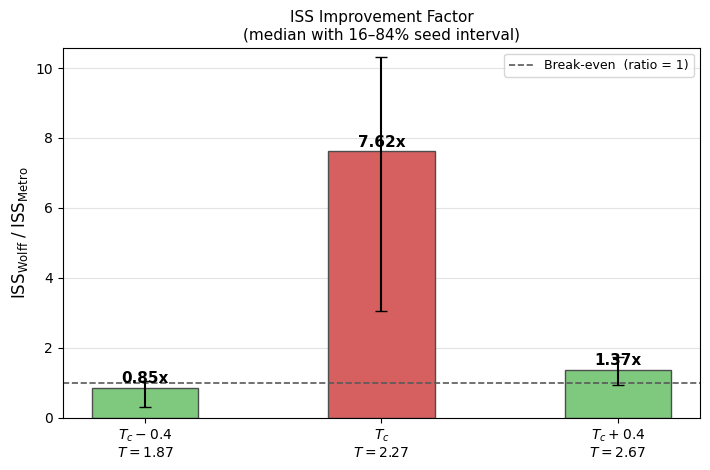


Context at selected temperatures (median values):
     T     <C>/L^2    tau_m_norm    tau_w_norm       ISS_m       ISS_w     ratio
 1.874      0.8995        1.7808        0.7228     5127.23     4183.11     0.853
 2.242      0.5008       37.1980        1.4129      103.39      500.10     7.615
 2.684      0.0053        4.4861        0.0843      542.71      652.85     1.375


In [15]:
t_targets = [TC_ISING - 0.4, TC_ISING, TC_ISING + 0.4]
bar_labels = [
    f'$T_c - 0.4$\n$T = {t_targets[0]:.2f}$',
    f'$T_c$\n$T = {t_targets[1]:.2f}$',
    f'$T_c + 0.4$\n$T = {t_targets[2]:.2f}$',
]
bar_colors = ['#7fc97f', PALETTE['wolff'], '#7fc97f']

ratio_med = []
ratio_p16 = []
ratio_p84 = []
context_rows = []

for Tt in t_targets:
    idx = int(np.argmin(np.abs(temperatures - Tt)))

    # Per-seed ratio distribution for uncertainty
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_samples = iss_wolff_norm_samples[idx] / iss_metro_norm_samples[idx]
    ratio_samples = ratio_samples[np.isfinite(ratio_samples)]

    if ratio_samples.size:
        med = float(np.nanmedian(ratio_samples))
        p16 = float(np.nanpercentile(ratio_samples, 16))
        p84 = float(np.nanpercentile(ratio_samples, 84))
    else:
        med = float('nan')
        p16 = float('nan')
        p84 = float('nan')

    ratio_med.append(med)
    ratio_p16.append(p16)
    ratio_p84.append(p84)

    context_rows.append({
        'T': float(temperatures[idx]),
        'tau_m_norm': float(tau_metro_norm[idx]),
        'tau_w_norm': float(tau_wolff_norm[idx]),
        'iss_m': float(iss_metro_norm[idx]),
        'iss_w': float(iss_wolff_norm[idx]),
        'cfrac': float(mean_cluster_frac[idx]),
    })

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x = np.arange(len(bar_labels))
vals = np.array(ratio_med)
err_low = np.clip(vals - np.array(ratio_p16), 0, None)
err_high = np.clip(np.array(ratio_p84) - vals, 0, None)
yerr = np.vstack([err_low, err_high])

bars = ax.bar(
    x,
    vals,
    yerr=yerr,
    color=bar_colors,
    width=0.45,
    zorder=2,
    edgecolor='0.3',
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.axhline(1.0, color='0.35', ls='--', lw=1.2, label='Break-even  (ratio = 1)')
ax.set_ylabel(r'$\mathrm{ISS}_{\mathrm{Wolff}}\;/\;\mathrm{ISS}_{\mathrm{Metro}}$', fontsize=12)
ax.set_title('ISS Improvement Factor\n(median with 16–84% seed interval)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35, zorder=0)

finite_vals = [v for v in vals if np.isfinite(v)]
if finite_vals:
    ax.set_ylim(0, max(finite_vals) * 1.35 + 0.3)

for bar, val in zip(bars, vals):
    if np.isfinite(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.2f}x',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
        )

fig.tight_layout()
plt.show()

print('\nContext at selected temperatures (median values):')
print(f'{"T":>6}  {"<C>/L^2":>10}  {"tau_m_norm":>12}  {"tau_w_norm":>12}  {"ISS_m":>10}  {"ISS_w":>10}  {"ratio":>8}')
for row, ratio in zip(context_rows, vals):
    print(
        f"{row['T']:>6.3f}  {row['cfrac']:>10.4f}  {row['tau_m_norm']:>12.4f}  {row['tau_w_norm']:>12.4f}  "
        f"{row['iss_m']:>10.2f}  {row['iss_w']:>10.2f}  {ratio:>8.3f}"
    )

## When to use Wolff

The uncertainty-aware ISS results above translate directly into the algorithm selection rule documented in `AGENTS.md`.

**Use `update='wolff'`** for equilibrium studies near criticality (roughly within 20% of $T_c$): finite-size scaling around susceptibility peaks, Binder-cumulant crossing analyses, or critical-exponent measurements. In this regime, the work-normalised $\tau_{\mathrm{int}}$ is much smaller for Wolff, and the higher ISS directly reduces statistical error at fixed wall time.

**Use `update='checkerboard'`** sufficiently far from $T_c$ when the ISS curves indicate no Wolff advantage. The checkerboard kernel is highly efficient for local updates, and at some temperatures the cluster overhead offsets Wolff's decorrelation gain.

**Core comparability rule:** never compare raw $\tau_{\mathrm{int}}$ step counts across algorithms. Always compare $\tau$ in common work units (here, $L^2$-sweep equivalents). ISS can be compared directly in 1/s and is shown with seed uncertainty bands.

**For kinetics studies**, avoid both checkerboard and Wolff: use `update='random'` to preserve the intended non-equilibrium Glauber-like dynamics.

For theoretical background — FK representation, cluster updates, and bond-addition probability derivation — see `PHYSICS.md`.

## Bibliography

[[1]](#Bibliography) W. K. Hastings, "Monte Carlo sampling methods using Markov chains and their applications," *Biometrika*, vol. 57, no. 1, pp. 97–109, 1970. [Oxford Academic](https://academic.oup.com/biomet/article/57/1/97/252073)

[[2]](#Bibliography) U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361–364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[[3]](#Bibliography) C. M. Fortuin and P. W. Kasteleyn, "On the random-cluster model. I. Introduction and relation to other models," *Physica*, vol. 57, no. 4, pp. 536–564, 1972. [Elsevier Open Access](https://doi.org/10.1016/0031-8914(72)90045-6)

[[4]](#Bibliography) M. E. J. Newman and G. T. Barkema, "Monte Carlo Methods in Statistical Physics," Oxford University Press, 1999. [Lecture Notes Summary (H. G. Katzgraber)](https://arxiv.org/abs/0905.1629)

[[5]](#Bibliography) A. D. Sokal, "Monte Carlo Methods in Statistical Mechanics: Foundations and New Algorithms," lecture notes (1989), published in *Functional Integration: Basics and Applications* (C. DeWitt-Morette, P. Cartier, A. Folacci, eds.), Springer, 1997, pp. 131–192. Standard reference for the integrated autocorrelation time and the automatic windowing estimator. [Springer Link](https://link.springer.com/chapter/10.1007/978-1-4899-0319-8_6)